In [38]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.integrate import quad

Computed Expectation: 4.983
Theoretical Mean: 5.0
Poisson - Computed Expectation: 2.97
Poisson - Theoretical Mean: 3
Exponential - Computed Expectation: 1.0290138887556537
Exponential - Theoretical Mean: 1.0


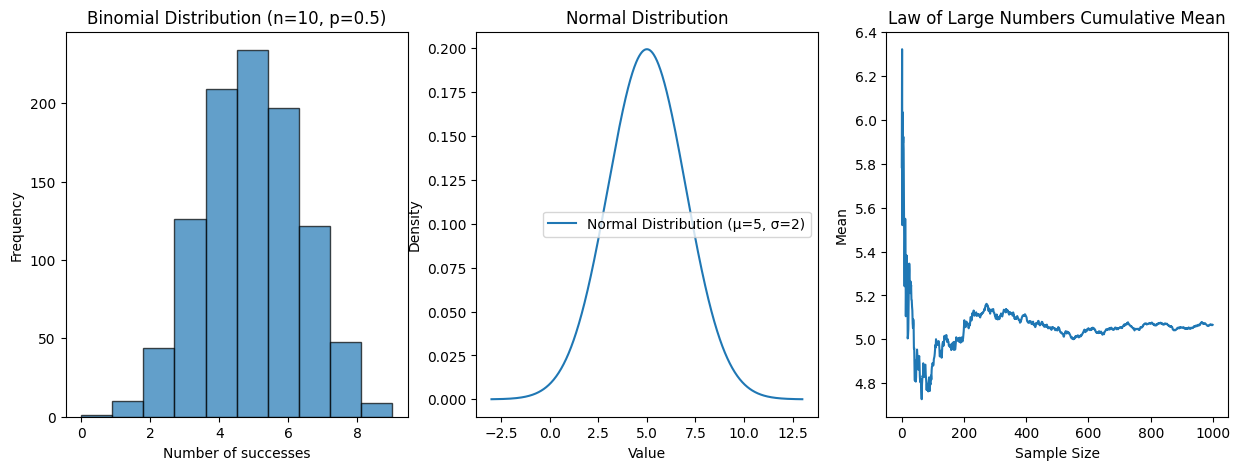

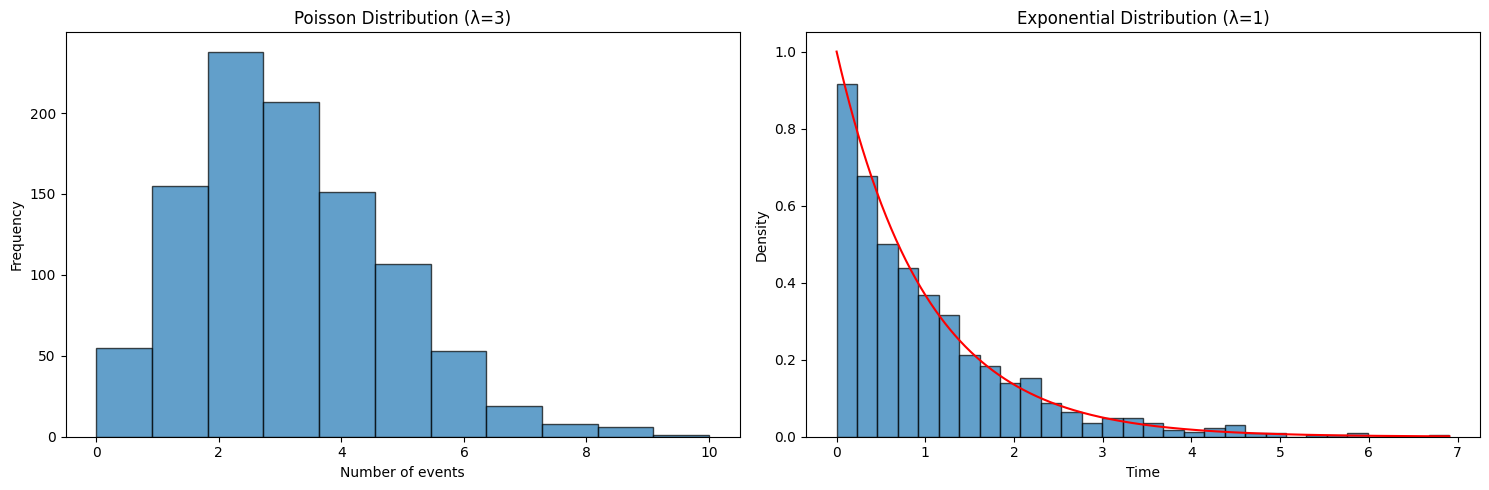

In [39]:
from scipy.stats import binom, norm, poisson, expon

# Binomial Distribution with n 10 mu 0.5
n, p = 10, 0.5
binomial_data = binom.rvs(n, p, size=1000)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.hist(binomial_data, bins=n, edgecolor='k', alpha=0.7)
plt.title('Binomial Distribution (n=10, p=0.5)')
plt.xlabel('Number of successes')
plt.ylabel('Frequency')

computed_expectation = np.mean(binomial_data)
theoretical_mean = n * p
print(f"Computed Expectation: {computed_expectation}")
print(f"Theoretical Mean: {theoretical_mean}")

# Normal Distribution with mu 5 sigma 2
mu, sigma = 5, 2
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.subplot(132)
plt.plot(x, y, label='Normal Distribution (μ=5, σ=2)')
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

sample_size = 1000
samples = np.random.normal(mu, sigma, sample_size)

cumulative_mean = np.cumsum(samples) / np.arange(1, sample_size + 1)
plt.subplot(133)
plt.plot(cumulative_mean)
plt.title('Law of Large Numbers Cumulative Mean')
plt.xlabel('Sample Size')
plt.ylabel('Mean')

# Poisson Distribution
lam = 3

data = poisson.rvs(lam, size=1000)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.hist(data, bins=max(data)-min(data)+1, edgecolor='k', alpha=0.7)
plt.title('Poisson Distribution (λ=3)')
plt.xlabel('Number of events')
plt.ylabel('Frequency')

computed_poisson_expectation = np.mean(data)
theoretical_poisson_mean = lam
print(f"Poisson - Computed Expectation: {computed_poisson_expectation}")
print(f"Poisson - Theoretical Mean: {theoretical_poisson_mean}")

# Exponential Distribution
lam = 1

edata = expon.rvs(scale=1/lam, size=1000)

plt.subplot(122)
plt.hist(edata, bins=30, density=True, edgecolor='k', alpha=0.7)
x = np.linspace(0, max(edata), 1000)
plt.plot(x, expon.pdf(x, scale=1/lam), 'r')
plt.title('Exponential Distribution (λ=1)')
plt.xlabel('Time')
plt.ylabel('Density')

computed_exponential_expectation = np.mean(edata)
theoretical_exponential_mean = 1/lam
print(f"Exponential - Computed Expectation: {computed_exponential_expectation}")
print(f"Exponential - Theoretical Mean: {theoretical_exponential_mean}")

plt.tight_layout()
plt.show()


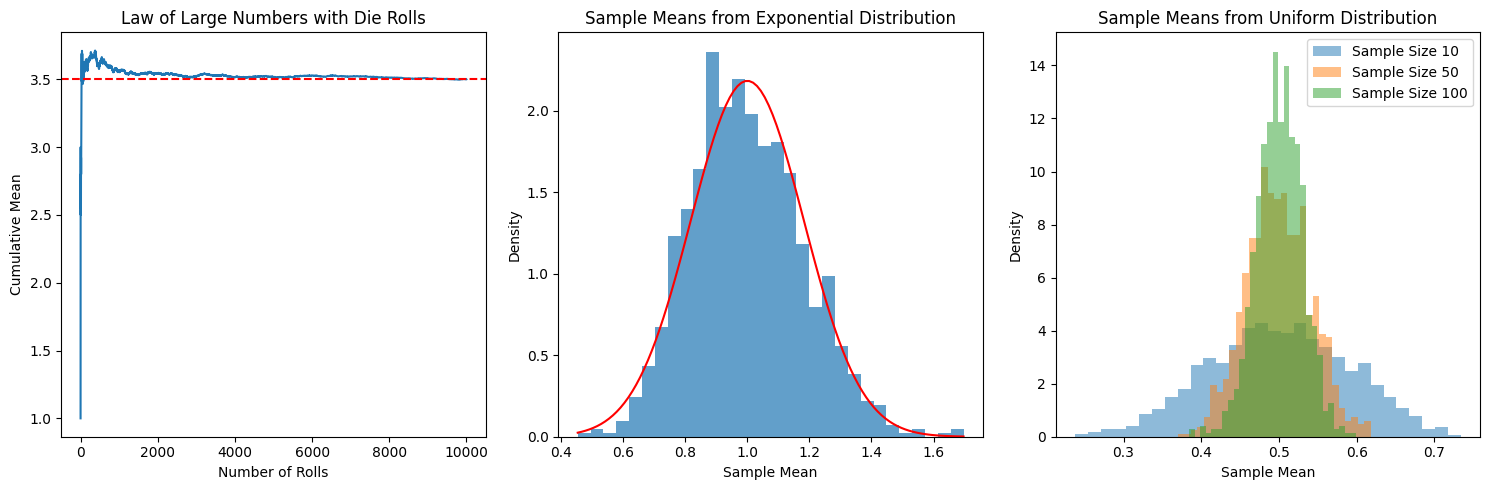

In [40]:
# Law of Large Numbers
roll = np.random.randint(1, 7, 10000)
cumulative_mean = np.cumsum(roll) / np.arange(1, len(roll) + 1)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.plot(cumulative_mean)
plt.title('Law of Large Numbers with Die Rolls')
plt.xlabel('Number of Rolls')
plt.ylabel('Cumulative Mean')
plt.axhline(y=3.5, color='r', linestyle='--')
# The cumulative mean converges to the expected value because the law of large numbers states
# That as sample size increases (we have it at 10000), cumulative mean converges to population mean/expected mean

# Central Limit Theorem with Exponential Distribution
lambda_param = 1
sample_sizes = 1000
sample_means = [np.mean(np.random.exponential(1/lambda_param, 30)) for _ in range(sample_sizes)]

plt.subplot(132)
plt.hist(sample_means, bins=30, density=True, alpha=0.7)
plt.title('Sample Means from Exponential Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Density')

# Theoretical Normal Distribution
theoretical_mean = 1/lambda_param
theoretical_std = (1/lambda_param) / np.sqrt(30)
x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, stats.norm.pdf(x, theoretical_mean, theoretical_std), 'r-')

# Uniform Distribution
sizes = [10, 50, 100]
plt.subplot(133)
for size in sizes:
    sample_means = [np.mean(np.random.uniform(0, 1, size)) for _ in range(1000)]
    plt.hist(sample_means, bins=30, density=True, alpha=0.5, label=f'Sample Size {size}')

plt.title('Sample Means from Uniform Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

Height Hypothesis Test:
1.4142135623730951
0.157299207050285
Fail to reject null hypothesis
T-Test
107.13059374161456
2.6241170876857978
0.013712534981979912
Reject null hypothesis
Actual Data
172.702508535872
173.442017606
1.3894992877882912
0.16779809223352488
Reject null hypothesis


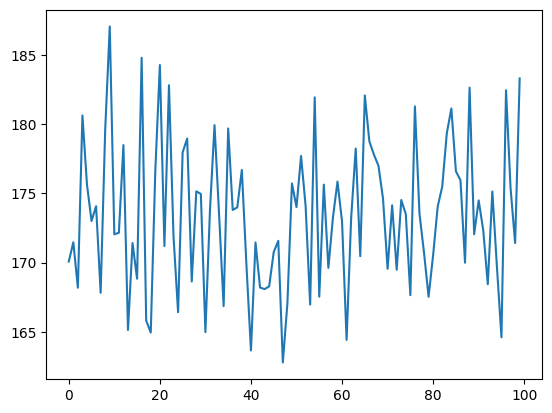

In [ ]:
# Height Hypothesis Test
population_mean = 170
population_std = 10
sample_size = 50
sample_mean = 172

z_value = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))

print("Height Hypothesis Test:")
print(z_value)
print(p_value)
print("Reject null hypothesis" if p_value < 0.05 else "Fail to reject null hypothesis")

# T-test with Normal Distributions
true_mean = 100
true_std = 15
sample_data = np.random.normal(true_mean, true_std, 30)

t_statistic, p_value = stats.ttest_1samp(sample_data, true_mean)

print("T-Test")
print(np.mean(sample_data))
print(t_statistic)
print(p_value)
print("Reject null hypothesis" if p_value < 0.05 else "Fail to reject null hypothesis")

# Actual data example
import pandas as pd

df = pd.read_csv('SOCR-HeightWeight.csv')

# Converting inches to cm to keep it consistent with earlier
heights = df['Height(Inches)'] * 2.54

samples = []
# Getting random samples from the data
for i in range(100):
    samples.append(np.random.choice(heights))

population_mean = np.mean(heights)

t_statistic1, p_value1 = stats.ttest_1samp(samples, population_mean)

print("Actual Data")
print(np.mean(heights))
print(np.mean(samples))
print(t_statistic1)
print(p_value1)
print("Reject null hypothesis" if p_value < 0.05 else "Fail to reject null hypothesis")
plt.plot(samples)
# The results make sense because the samples are directly sampled from the dataset where the population mean is taken
# This makes it highly unlikley that the sample mean differs much from the population mean


In [42]:
def f(x):
    return np.log(x) + x**3

def df_analytical(x):
    return 1/x + 3*x**2

def g(x, y):
    return x**3 + y**3 + x*y

def partial_x(x, y, h):
    return (g(x + h, y) - g(x - h, y)) / (2 * h)

def partial_y(x, y, h):
    return (g(x, y + h) - g(x, y - h)) / (2 * h)

def h_func(x, y):
    return np.sin(x) * np.cos(y)

def h_gradient_analytical(x, y):
    return np.cos(x) * np.cos(y), -np.sin(x) * np.sin(y)

# Derivative of f(x) using central difference
x = 2
h = 0.01
numerical_derivative = (f(x + h) - f(x - h)) / (2 * h)
analytical_derivative = df_analytical(x)

print("Derivative of f(x)")
print(numerical_derivative)
print(analytical_derivative)

# Partial Derivatives
x, y = 1, 2
h = 0.01
partial_x_value = partial_x(x, y, h)
partial_y_value = partial_y(x, y, h)

print("Partial Derivatives")
print(partial_x_value)
print(partial_y_value)

# Gradient of h
x, y = np.pi/4, np.pi/4
h_val = 0.01

# Numerical gradient for x
def h_x(x_val):
    return h_func(x_val, y)

# Numerical gradient for y
def h_y(y_val):
    return h_func(x, y_val)

h_grad_x = (h_x(x + h_val) - h_x(x - h_val)) / (2 * h_val)
h_grad_y = (h_y(y + h_val) - h_y(y - h_val)) / (2 * h_val)

analytical_gradient = h_gradient_analytical(x, y)

print("Gradient of h(x,y)")
print(h_grad_x, h_grad_y)
print(analytical_gradient)

Derivative of f(x)
12.50010416672902
12.5
Partial Derivatives
5.000099999999907
13.000099999999826
Gradient of h(x,y)
0.4999916667083326 -0.4999916667083354
(0.5000000000000001, -0.5000000000000001)


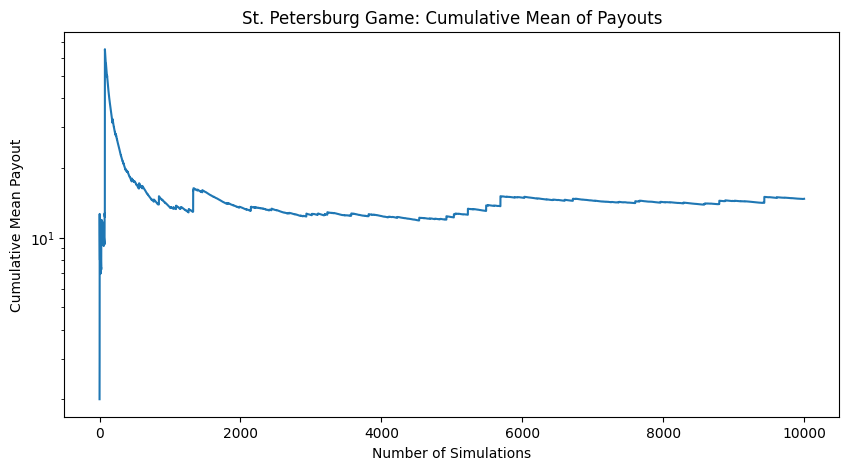

Final Cumulative Mean: 14.726


In [43]:
def st_petersburg_game():
    flips = 0
    while True:
        flips += 1
        if np.random.random() < 0.5:
            return 2**flips

num_simulations = 10000
payouts = [st_petersburg_game() for _ in range(num_simulations)]

cumulative_mean = np.cumsum(payouts) / np.arange(1, len(payouts) + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_mean)
plt.title('St. Petersburg Game: Cumulative Mean of Payouts')
plt.xlabel('Number of Simulations')
plt.ylabel('Cumulative Mean Payout')
plt.yscale('log')
plt.show()

print(f"Final Cumulative Mean: {cumulative_mean[-1]}")

# Because payout does not converge, there is no fair price for this game
# In real world scenarios this has a few implications
# You cannot price something solely based on the expected payout
# A real world application of exploding moments could be insurance
# When paying for insurance there are basically an infinite number of outcomes to consider
# However pricing the insurance based on the expected payout of all the possibilites is unreasonable unless someone is super rich
# This leads to a fair price problem similar to St. Petersburg's paradox
# Also any game involving an infinite cost such as the proposed infinite fair price of the St. Petersburg game breaks down in real life
# You have to take into account the amount that people are realistically willing to pay
# Because life is not just about expected value

0.8872257053638565


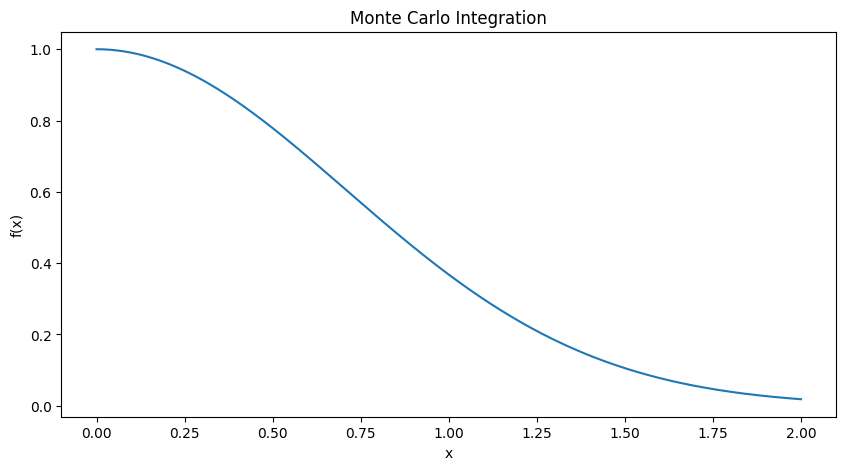

3.1664
3.141592653589793


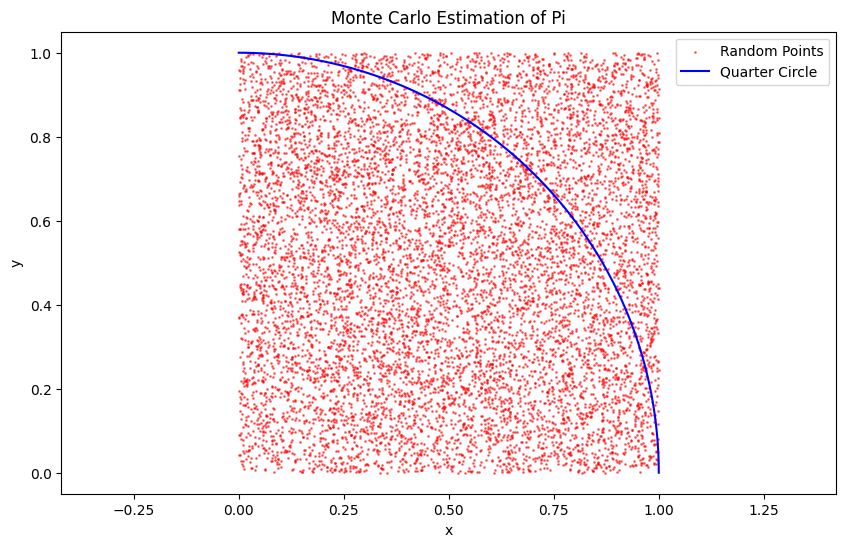

Simulation of Sum of Random Variables
1.542588809967472
1.1620649199121116
Theoretical
1.5
1.0833333333333333


In [44]:
# Monte Carlo Integration
def f(x):
    return np.exp(-x**2)

def monte_carlo_integration(func, a, b, num_samples):
    x = np.random.uniform(a, b, num_samples)
    y = func(x)
    integral = (b - a) * np.mean(y)
    return integral

num_samples = 10000
a, b = 0, 2
integral = monte_carlo_integration(f, a, b, num_samples)
print(integral)

plt.figure(figsize=(10, 5))
x_plot = np.linspace(a, b, 200)
plt.plot(x_plot, f(x_plot))
plt.title('Monte Carlo Integration')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

# Estimating π
def estimate_pi(num_points):
    x = np.random.uniform(0, 1, num_points)
    y = np.random.uniform(0, 1, num_points)
    inside_circle = np.sum((x**2 + y**2) <= 1)
    pi_estimate = 4 * inside_circle / num_points
    return pi_estimate, x, y

num_points = 10000
pi_estimate, x, y = estimate_pi(num_points)

print(pi_estimate)
print(np.pi)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', s=1, alpha=0.5, label='Random Points')
theta = np.linspace(0, np.pi/2, 1000)
plt.plot(np.cos(theta), np.sin(theta), label='Quarter Circle', color='blue')
plt.title('Monte Carlo Estimation of Pi')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.show()

# Monte Carlo Simulation for Random Variables
uniform_samples = np.random.uniform(0, 1, 1000)
exponential_samples = np.random.exponential(1, 1000)

combined_samples = uniform_samples + exponential_samples

print("Simulation of Sum of Random Variables")
print(np.mean(combined_samples))
print(np.var(combined_samples))

theoretical_mean = (0 + 1/2) + (1/1)
theoretical_variance = (1/12) + (1/1)

print("Theoretical")
print(theoretical_mean)
print(theoretical_variance)